In [1]:
%%writefile /tmp/study_ipc.cpp
extern "C" long ipc_chain(long x) {
    x = x * 31 + 7;
    x = x * 31 + 7;
    x = x * 31 + 7;
    x = x * 31 + 7;
    x = x * 31 + 7;
    return x;
}
extern "C" long ipc_parallel(long a, long b, long c, long d) {
    return a * 31 + b * 31 + c * 31 + d * 31;
}

Overwriting /tmp/study_ipc.cpp


In [2]:
!g++ -std=c++23 -O3 -c /tmp/study_ipc.cpp -o /tmp/study_ipc.o

In [3]:
import pandas as pd

import perf

inputs = {
    "ipc_chain": {"rdi": 42},
    "ipc_parallel": {"rdi": 42, "rsi": 43, "rdx": 44, "rcx": 45},
}
frames = []
for func in ("ipc_chain", "ipc_parallel"):
    df = perf.bench(
        file="/tmp/study_ipc.o",
        target=func,
        mode="latency",
        event="topdown-retiring,topdown-bad-spec,topdown-fe-bound,topdown-be-bound",
        config={"samples": 60, "runs": 4, "iterations": 300},
        data=inputs[func],
    ).reset_index()
    df["func"] = func
    frames.append(df)
top = pd.concat(frames, ignore_index=True)
med = top.groupby("func")[
    ["topdown-retiring", "topdown-bad-spec", "topdown-fe-bound", "topdown-be-bound"]
].median()
pct = med.div(med.sum(axis=1), axis=0).round(3)
print(med.round(1))
print(pct)

              topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
func                                                                 
ipc_chain                 27.0              10.0               0.0   
ipc_parallel              13.0               5.0               1.0   

              topdown-be-bound  
func                            
ipc_chain                 11.0  
ipc_parallel               1.0  
              topdown-retiring  topdown-bad-spec  topdown-fe-bound  \
func                                                                 
ipc_chain                0.562             0.208              0.00   
ipc_parallel             0.650             0.250              0.05   

              topdown-be-bound  
func                            
ipc_chain                0.229  
ipc_parallel             0.050  


In [4]:
import pandas as pd

import perf

frames = []
for func in ("ipc_chain", "ipc_parallel"):
    df = perf.bench(
        file="/tmp/study_ipc.o",
        target=func,
        mode="latency",
        event="cycles,instructions",
        config={"samples": 60, "runs": 4, "iterations": 300},
        data=inputs[func],
    ).reset_index()
    df["func"] = func
    frames.append(df)
cmp = pd.concat(frames, ignore_index=True)
cmp["ipc"] = cmp["instructions"] / cmp["cycles"]
print(cmp.groupby("func")[["cycles", "instructions", "ipc"]].median().round(2))

              cycles  instructions   ipc
func                                    
ipc_chain       10.0          25.0  2.50
ipc_parallel     7.0          11.0  1.57


/home/kris/.local/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
/home/kris/.local/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)
/home/kris/.local/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


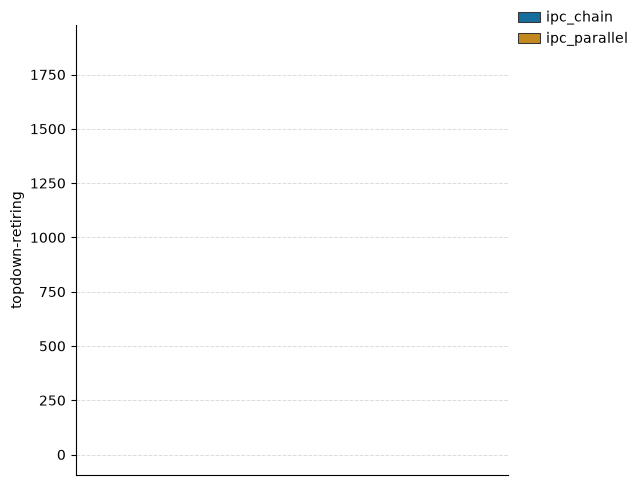

/home/kris/.local/lib/python3.11/site-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


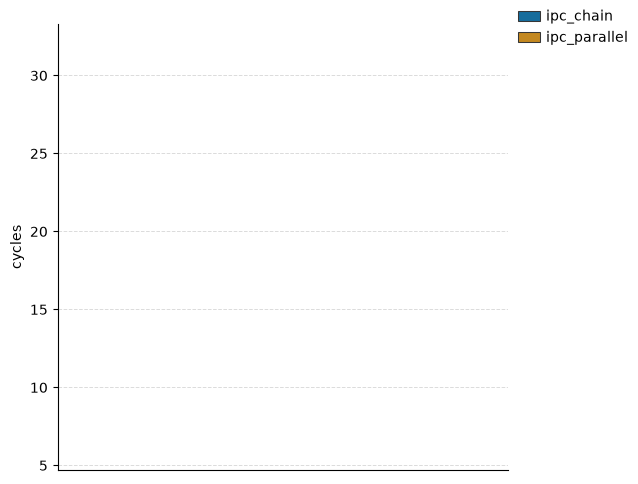

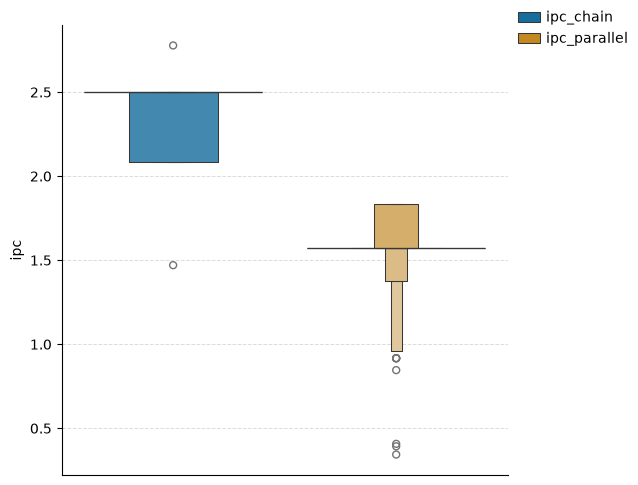

[]

In [5]:
perf.plot(
    top,
    "boxen",
    event="topdown-retiring,topdown-bad-spec,topdown-fe-bound,topdown-be-bound",
    groupby="func",
)
perf.plot(cmp, "boxen", event="cycles,instructions", groupby="func")
perf.plot(cmp, "boxen", event="ipc", groupby="func")